In [2]:
!pip3 install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 MB 4.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 7.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 22.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.2/133.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 14.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 10.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 3.1 MB/s eta 0:00:00a 0:00:01


In [5]:
!pip3 install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 982.1 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 1.4 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 891.7 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 3.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 10.2 MB/s eta 0:00:00


In [26]:
import sys
print(sys.executable)
print(sys.version)
print(sys.version_info)

/opt/homebrew/opt/python@3.11/bin/python3.11
3.11.6 (main, Oct  2 2023, 13:45:54) [Clang 15.0.0 (clang-1500.0.40.1)]
sys.version_info(major=3, minor=11, micro=6, releaselevel='final', serial=0)


torch.Size([11]) torch.Size([11])


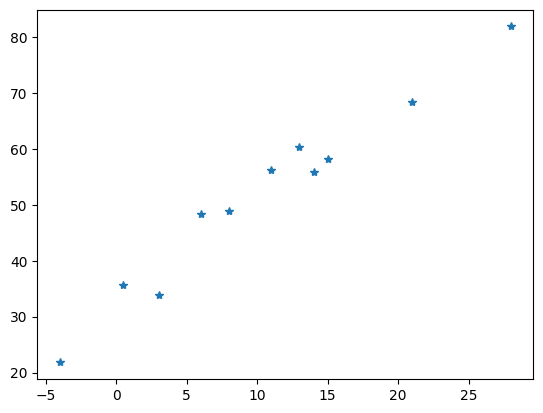

In [58]:
import numpy as np
import torch as t
from matplotlib import pyplot as plt
x_s =  [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
y_s =  [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
x_t = t.tensor(x_s) # convert to tensor in pytorch 
y_t = t.tensor(y_s)
print(x_t.shape, y_t.shape)
plt.plot(x_s,y_s,'*')
plt.show()


In [28]:
import random


In [29]:
# normalize the data
from torch.nn.functional import normalize
x_n = (x_t - t.mean(x_t))/t.std(x_t) # normalize(x_t, 2, dim = 0)# (x_t - t.mean(x_t))/t.std(x_t)
x_n


tensor([-1.0856,  0.3800,  0.4885,  1.8998,  0.0543, -0.2714, -0.8142, -1.5741,
        -0.4885,  0.2714,  1.1399])

In [30]:
y_n = (y_t - t.mean(y_t))/t.std(y_t)
y_n

tensor([-0.9565,  0.2436,  0.3802,  1.7883,  0.2673, -0.1723, -1.0635, -1.7823,
        -0.2020,  0.5109,  0.9862])

In [31]:
# define a linear model y = w * x + b (a line)
# find parameters a and b that minimize the error between the points 
# and the line
def model(x, w, b): 
    return w * x + b

# error (mean squared error)
# y_predict is a tensor (a vector of values) comes from the model, 
# y_true = true values - come from the training data 
def loss_fn(y_predict, y_true):
    squared_diffs = (1/2)*(y_true - y_predict)**2  # tensor of  errors
    return squared_diffs.mean() # sum of errors/# points



tensor(0.1000) tensor(-0.)


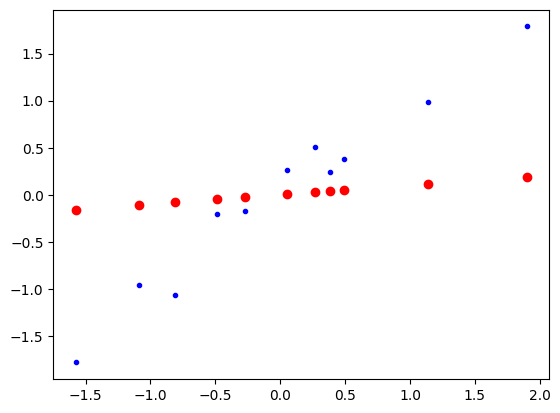

Initial loss =  tensor(0.3699)


In [32]:
w = 0.1*t.ones(())  # w = 1
b = -0.2*t.zeros(()) # b = 0
print(w, b)
y_p = model(x_n, w, b)
plt.plot(x_n, y_p,'ro')
plt.plot(x_n, y_n, 'b.')
plt.show()

# compute the error
loss0 = loss_fn(y_p,y_n)
print("Initial loss = ", loss0)

In [13]:
# gradient of loss with respect to w and b
# dLoss/dw = d (y_p - y_t)^2)/dw = dLoss/dy_p * dy_p/dw 
#          = 2 (y_p-y_t) * dy_p/dw = 
#          = 2 (y_p-y_t) * d(w*x_t + b)/dw = 
#          = 2 (y_p-y_t) * x_t
# dLoss/db = d(y_p - y_t)^2/db= dLoss/dy_p * dy_p/db =
#           = 2 (y_p-y_t) * dy_p/db =
#           = 2 (y_p-y_t) * d(w*x_t + b)/db = 
#           = 2 (y_p-y_t) 
# d x^2 / d x = 2 x 
def grad_loss (y_p, y_t):
    return (y_p-y_t)/y_p.size(0)         # y_p.size(0) = n 
    
def grad_w(x_t, w, b):
    return x_t
  
def grad_b(x_t, w, b):
    return 1.0


In [33]:
# gradient descent
def training_loop(n_epochs, learning_rate, w,b  , y_t, x_t, eps = 1e-3):
    for epoch in range(1, n_epochs + 1):
        # forward pass:
        y_p  = model(x_t,w,b)   # compute the model's prediction for all x_t points
        # backward pass
        loss = loss_fn(y_p, y_t) 
        grad_all = grad_loss(y_p,y_t)  # tensor
        w = w - learning_rate * (grad_all * grad_w(x_t, w, b)).sum()
        b = b - learning_rate * (grad_all * grad_b(x_t, w, b)).sum()
        if epoch % 5 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss) ) ) 
        if (loss < eps):
            break
    return w,b

In [34]:
w = 0.1*t.ones(()) # w = 1
b = 0.1*t.ones(()) # b = 0
learning_rate = 0.2 # 0.005 # learning rate 0.1, 0.01 # change it to smaller values
w_train, b_train = training_loop(50, learning_rate, w, b, y_n, x_n, 0.01)

Epoch 5, Loss 0.088913
Epoch 10, Loss 0.026863
Epoch 15, Loss 0.018541
Epoch 20, Loss 0.017425
Epoch 25, Loss 0.017275
Epoch 30, Loss 0.017255
Epoch 35, Loss 0.017252
Epoch 40, Loss 0.017252
Epoch 45, Loss 0.017252
Epoch 50, Loss 0.017252


In [35]:
print(w_train)
print(b_train)

tensor(0.9808)
tensor(1.2966e-06)


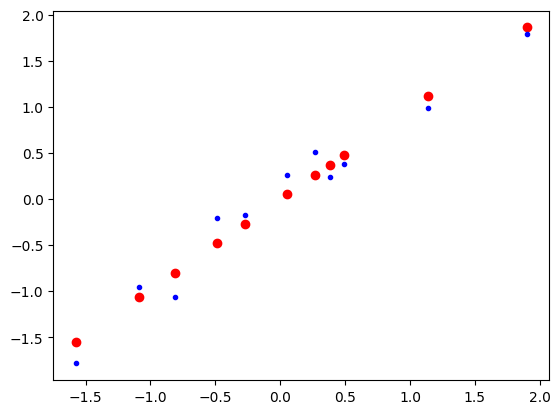

In [36]:
plt.plot(x_n, model(x_n, w_train, b_train), 'ro')
plt.plot(x_n, y_n, 'b.')
plt.show()

In [19]:
import torch.nn as nn   # neural network module 
import torch.optim as optim # optimization module (SGD)

# nn.Linear(input_size, output_size, bias = True)
linear_model = nn.Linear(1, 1) # one neuron similar to y = w*x + b
                             # nn.Linear(2,1)  y = w1*x1 + w2*x2 + b
                             # nn.Linear(2,2)  y1 = w11*x1 + w12*x2 + b1
                             #                 y2 = w21*x1 + w22*x2 + b2
print(linear_model.weight, linear_model.bias)
print(linear_model.parameters)


Parameter containing:
tensor([[-0.5302]], requires_grad=True) Parameter containing:
tensor([0.0686], requires_grad=True)
<bound method Module.parameters of Linear(in_features=1, out_features=1, bias=True)>


In [20]:
x = t.ones(2,1)
print(x, x.shape)
linear_model(x)

tensor([[1.],
        [1.]]) torch.Size([2, 1])


tensor([[-0.4615],
        [-0.4615]], grad_fn=<AddmmBackward0>)

In [53]:
# split training - validation
n_samples = x_t.shape[0]
n_val = int(0.3 * n_samples) # 20 % of the samples for validation
shuffled_indices = t.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]
print(train_indices, val_indices)


tensor([7, 5, 6, 3, 9, 4, 2, 1]) tensor([ 8, 10,  0])


In [54]:
x_t_2d = x_n.unsqueeze(1) # adds a dimension
y_t_2d = y_n.unsqueeze(1)
#print(x_t_2d)
print(x_t_2d.shape)
print(y_t_2d.shape)

x_t_train = x_t_2d[train_indices,:]
x_t_val   = x_t_2d[val_indices,:]

y_t_train = y_t_2d[train_indices,:]
y_t_val   = y_t_2d[val_indices,:]

torch.Size([11, 1])
torch.Size([11, 1])


In [40]:

def training_loop(n_epochs, optimizer, model, loss_fn, x_t_train, x_t_val,
                  y_t_train, y_t_val, eps = 0.01):
    
    for epoch in range(1, n_epochs + 1):
        # forward pass training
        y_p_train  = model(x_t_train)
        loss_train = loss_fn(y_p_train, y_t_train)
 
        
        # backwards training
        optimizer.zero_grad()  # sets gradients to 0 
        loss_train.backward()  # gradients are computed 
        optimizer.step()       # parameters ar changed

        if epoch == 1 or epoch % 10 == 0:
            # forward pass validation
            y_p_val    = model(x_t_val)
            loss_val = loss_fn(y_p_val, y_t_val)
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
f" Validation loss {loss_val.item():.4f}")
        if loss_train < eps:
            break;

In [24]:
linear_model = nn.Linear(1, 1)  # one input and one output y = w x + b
print(linear_model.parameters(0), linear_model.parameters(1))
optimizer = optim.SGD(linear_model.parameters(), lr= 0.1)  # lr = learning rate
training_loop(n_epochs = 100, optimizer = optimizer,  
              model    = linear_model,
             loss_fn   = nn.MSELoss(), # error function = MSE = Mean Square Error
             x_t_train = x_t_train,  x_t_val= x_t_val,
             y_t_train = y_t_train, y_t_val = y_t_val, eps = 0.01)
# split data into training and validation


<generator object Module.parameters at 0x294e4fe60> <generator object Module.parameters at 0x294e4fca0>
Epoch 1, Training loss 4.1211, Validation loss 0.8682
Epoch 10, Training loss 0.0742, Validation loss 0.0819
Epoch 20, Training loss 0.0340, Validation loss 0.0470
Epoch 30, Training loss 0.0337, Validation loss 0.0438
Epoch 40, Training loss 0.0337, Validation loss 0.0435
Epoch 50, Training loss 0.0337, Validation loss 0.0434
Epoch 60, Training loss 0.0337, Validation loss 0.0434
Epoch 70, Training loss 0.0337, Validation loss 0.0434
Epoch 80, Training loss 0.0337, Validation loss 0.0434
Epoch 90, Training loss 0.0337, Validation loss 0.0434
Epoch 100, Training loss 0.0337, Validation loss 0.0434


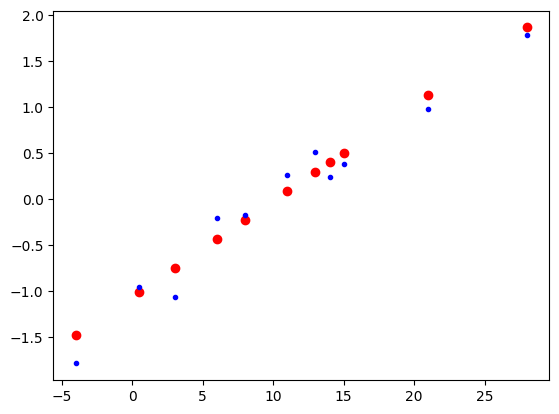

In [60]:
y_p = linear_model(x_t_2d).squeeze(1).detach()
plt.plot(x_t, y_p, 'ro') # .parameters(0), linear_model.parameters(1)), 'ro')
plt.plot(x_t, y_n, 'b.')
plt.show()

In [49]:
y_t

tensor([-1.0056,  0.4048,  0.5093,  1.8674,  0.0914, -0.2220, -0.7444, -1.4757,
        -0.4310,  0.3003,  1.1361], grad_fn=<SqueezeBackward1>)